In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
import time
from mpl_toolkits.mplot3d import Axes3D 
import scipy
import sys

In [2]:
import gymnasium
from gymnasium import spaces

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp 
from deap import base
from deap import creator
from deap import tools
import random
import seaborn as sns
import gudhi as gd
from stable_baselines3.common.vec_env import SubprocVecEnv
from pathos.multiprocessing import ProcessingPool as Pool

In [4]:
from topology_utils import deconstruct, calculate_smoothness_metric, count_islands_dfs, return_topology_slice

In [5]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [6]:
sys.path.append('../../../../../../ocean_intella/ocean_intella/pipelay_profile_optimization/')

In [7]:
import elitism

In [8]:
x0, y0 = 36, 36

### Finite Element Model

In [9]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
#     print(params)
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=0):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = 1
    return normals, forces, density

In [10]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [11]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [12]:
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)

In [13]:
def compliance(x_phys, u, ke, *, penal=3, e_min=1e-9, e_0=1):
    nely, nelx = x_phys.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords for the index map

    n1 = (nely+1)*(elx+0) + (ely+0)  # nodes
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    all_ixs = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    u_selected = u[all_ixs]  # select from u matrix

    ke_u = anp.einsum('ij,jkl->ikl', ke, u_selected)  # compute x^penal * U.T @ ke @ U
    ce = anp.einsum('ijk,ijk->jk', u_selected, ke_u)
    C = young_modulus(x_phys, e_0, e_min, p=penal) * ce.T
    return anp.sum(C)

def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [14]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs], sym_pos=True)
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [15]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [16]:
def _get_solver(a_entries, a_indices, size, sym_pos):
    # a is (usu.) symmetric positive; could solve 2x faster w/sksparse.cholmod.cholesky(a).solve_A
    a = scipy.sparse.coo_matrix((a_entries, a_indices), shape=(size,)*2).tocsc()
    return scipy.sparse.linalg.splu(a).solve


def solve_coo(a_entries, a_indices, b, sym_pos=False):
    solver = _get_solver(a_entries, a_indices, b.size, sym_pos)
    return solver(b)

def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

In [17]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [18]:
def draw(X):  
    plt.figure(dpi=50) 
    print('\nFinal Cantilever beam design:')
    plt.imshow(X) 
    plt.show()

### Genetic Modelling

In [19]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 2000
HALL_OF_FAME_SIZE = 30

In [20]:
PENALTY_VALUE = 1000.0 

In [21]:
# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [22]:
toolbox = base.Toolbox()

In [23]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [24]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [25]:
# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

In [26]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", 
                 tools.initRepeat,
                 creator.Individual,
                 toolbox.zeroOrOne, 
                 x0*y0+4)

In [27]:
# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", 
                 tools.initRepeat, 
                 list, 
                 toolbox.individualCreator)

In [28]:
# convert a binary list to decimal
def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [29]:
class Prev:
    def __init__(self):
        self.prev = 100

In [30]:
T=Prev()

In [31]:
# fitness calculation
def staticFEM(individual):
    
    args = get_args(*mbb_beam(rd=0))
    
    x = np.array([t if t==1 else 1e-4 for t in individual[:-4]]) 
    
    
    try:
        if np.sum(x)/(x0*y0) > 0.5:
            tmp, const = fast_stopt(args, x)
            T.prev=tmp
            if const>(55+binatodeci(individual[-4:]))/100:
                return PENALTY_VALUE, 
        else:
            return T.prev,
    except:
        return PENALTY_VALUE, 
    
    
    return tmp,  # return a tuple

In [32]:
toolbox.register("evaluate", staticFEM)
pool = Pool(8)
toolbox.register("map", pool.map)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/(x0*y0+4))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Process ForkPoolWorker-1:
Process ForkPoolWorker-8:
Process ForkPoolWorker-7:
Process ForkPoolWorker-3:
Process ForkPoolWorker-2:
Process ForkPoolWorker-6:
Process ForkPoolWorker-4:
Process ForkPoolWorker-5:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framewor

  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/dill/_dill.py", line 423, in save
    StockPickler.save(self, obj, save_persistent_id)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/pickle.py", line 560, in save
    f(self, obj)  # Call unbound method with explicit self
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/pickle.py", line 886, in save_tuple
    save(element)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/dill/_dill.py", line 423, in save
    StockPickler.save(self, obj, save_persistent_id)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/pickle.py", line 560, in save
    f(self, obj)  # Call unbound method with explicit self
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/pickle.py", line 886, in save_tuple
    save(element)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-pac

In [33]:
# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with hof feature added:
    population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])
    print()
    
    x = np.array(best[:-4]).astype(np.float64).reshape(x0,y0)
    
    args = get_args(*mbb_beam(rd=0))
    print(fast_stopt(args, x))
    
    draw(x)
    

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
  
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')
    plt.show()    
    return x

gen	nevals	min	avg   
0  	300   	100	979084
1  	251   	100	898.321
2  	246   	100	1254.47
3  	245   	100	504.83 
4  	250   	100	146177 
5  	250   	100	842.651
6  	246   	100	176.671
7  	240   	100	104637 
8  	241   	100	42803.9
9  	241   	99.1831	21200.8
10 	243   	95.4543	341.277
11 	256   	88.4254	83662.3
12 	238   	88.4254	218.623
13 	256   	83.095 	41972.2
14 	246   	80.2278	126.241
15 	246   	78.5177	140.64 
16 	246   	75.628 	209.655
17 	249   	74.0027	103.766
18 	241   	63.7128	188.712
19 	241   	63.7128	187.755
20 	238   	63.7128	80.4287
21 	236   	63.6314	75.2676
22 	247   	59.8555	72.11  
23 	247   	59.8555	69.316 
24 	247   	58.8668	66.7791
25 	247   	58.6403	64.2672
26 	243   	58.6403	62.5872
27 	235   	54.4953	61.4333
28 	246   	54.2516	60.5389
29 	246   	53.3998	59.5587
30 	235   	53.0833	58.5594
31 	249   	52.6883	57.3603
32 	245   	51.0361	56.1525
33 	240   	51.0361	54.9107
34 	256   	51.0347	53.8321
35 	234   	50.5826	53.1358
36 	245   	49.7747	52.6467
37 	245   	49.77

304	256   	33.3913	165.642
305	248   	33.299 	168.827
306	237   	33.2893	168.815
307	243   	33.2893	168.793
308	252   	33.2785	165.542
309	243   	33.2363	149.396
310	237   	33.2363	133.258
311	240   	33.1892	155.794
312	252   	33.1892	184.782
313	245   	33.1892	158.987
314	242   	33.1892	142.864
315	239   	33.1668	155.743
316	251   	33.1541	165.409
317	247   	33.1541	133.163
318	251   	33.1541	149.258
319	250   	33.14  	142.832
320	253   	33.14  	110.559
321	256   	33.1091	133.101
322	251   	33.1091	155.651
323	254   	33.0839	155.645
324	248   	33.0839	139.525
325	242   	33.0816	123.395
326	235   	33.058 	129.828
327	237   	33.058 	142.714
328	251   	33.0572	149.147
329	236   	32.9906	149.139
330	245   	32.9846	149.131
331	246   	32.9846	158.795
332	241   	32.9826	152.337
333	246   	32.9393	197.468
334	240   	32.9138	158.805
335	251   	32.8872	174.903
336	240   	32.8619	103.951
337	240   	32.8619	136.156
338	254   	32.82  	142.576
339	233   	32.8166	129.652
340	250   	32.7862	100.613
3

608	241   	28.1551	135.127
609	257   	28.1502	141.596
610	237   	28.1413	141.584
611	243   	28.1184	144.815
612	247   	28.1179	118.891
613	245   	28.096 	157.756
614	244   	28.096 	131.833
615	246   	28.0947	160.993
616	251   	28.0717	141.546
617	247   	28.0688	131.816
618	243   	28.0468	131.809
619	254   	28.046 	125.311
620	251   	28.0091	99.3751
621	253   	28.0091	154.449
622	255   	27.9913	134.991
623	250   	27.9841	157.657
624	252   	27.9562	134.968
625	249   	27.9322	112.286
626	240   	27.9185	121.991
627	255   	27.9185	151.125
628	248   	27.9183	141.395
629	248   	27.8902	121.946
630	248   	27.8902	134.888
631	252   	27.8682	128.397
632	249   	27.8682	121.907
633	246   	27.8682	108.935
634	237   	27.8682	128.377
635	241   	27.8594	151.047
636	255   	27.8594	125.12 
637	247   	27.859 	121.873
638	240   	27.8461	105.665
639	242   	27.8447	99.1779
640	252   	27.8447	112.145
641	240   	27.8447	134.821
642	246   	27.8415	125.097
643	251   	27.8371	105.647
644	253   	27.8367	131.578
6

912	244   	25.1676	25.2198
913	247   	25.1632	25.212 
914	258   	25.1527	28.4427
915	248   	25.1158	25.1847
916	237   	25.0976	25.1727
917	233   	25.0976	28.409 
918	246   	25.0571	25.1455
919	251   	25.0484	25.1294
920	255   	25.0389	25.1132
921	246   	25.0155	25.0949
922	249   	25.0074	25.0738
923	248   	24.9694	25.0597
924	253   	24.9529	25.042 
925	248   	24.9387	25.0264
926	231   	24.9364	25.0061
927	250   	24.9163	24.9866
928	240   	24.9122	24.9646
929	241   	24.8897	24.9497
930	253   	24.8777	24.9402
931	255   	24.8623	24.9199
932	246   	24.8512	24.9143
933	238   	24.8334	24.8969
934	235   	24.832 	24.8853
935	234   	24.818 	24.8702
936	243   	24.818 	24.8621
937	247   	24.7919	24.8457
938	250   	24.7894	24.8376
939	255   	24.7774	24.8277
940	244   	24.7577	24.8162
941	254   	24.7489	24.8057
942	254   	24.716 	24.7976
943	251   	24.7135	24.7834
944	250   	24.7034	24.7677
945	250   	24.6941	24.7551
946	243   	24.6757	24.7474
947	248   	24.6757	24.729 
948	247   	24.6557	24.7181
9

1208	237   	23.1699	130.66 
1209	240   	23.1699	137.161
1210	257   	23.1699	124.155
1211	256   	23.1691	150.174
1212	242   	23.1691	124.12 
1213	239   	23.1681	156.682
1214	248   	23.1626	117.605
1215	247   	23.1626	130.628
1216	244   	23.1584	130.635
1217	245   	23.1583	107.842
1218	242   	23.1499	85.0362
1219	252   	23.1499	120.867
1220	250   	23.1499	130.622
1221	255   	23.147 	172.947
1222	254   	23.147 	156.668
1223	253   	23.147 	124.104
1224	244   	23.147 	133.871
1225	247   	23.1449	124.109
1226	245   	23.1438	98.0564
1227	240   	23.143 	111.139
1228	234   	23.1413	127.39 
1229	246   	23.1356	111.081
1230	245   	23.1356	101.304
1231	250   	23.1348	124.097
1232	243   	23.1348	98.0433
1233	251   	23.1306	114.319
1234	249   	23.1306	98.0386
1235	243   	23.1306	81.7838
1236	244   	23.1306	71.9842
1237	237   	23.1306	81.7537
1238	240   	23.1306	81.7534
1239	241   	23.1306	88.2626
1240	251   	23.1215	55.7102
1241	249   	23.1215	85.0082
1242	245   	23.1215	85.0112
1243	245   	23.12  	

1501	248   	22.9151	45.729 
1502	248   	22.9151	48.9757
1503	251   	22.9151	39.2014
1504	244   	22.9151	32.691 
1505	234   	22.9151	42.4583
1506	252   	22.9151	48.9734
1507	247   	22.9151	42.4608
1508	241   	22.9151	39.2019
1509	243   	22.9151	42.4626
1510	250   	22.9151	48.9767
1511	249   	22.9151	48.9719
1512	243   	22.9151	48.9721
1513	252   	22.9151	45.7175
1514	249   	22.9151	52.2316
1515	242   	22.9151	32.6965
1516	248   	22.9151	55.4866
1517	251   	22.9151	45.7161
1518	245   	22.9151	35.9456
1519	247   	22.9151	45.7161
1520	245   	22.9151	42.4685
1521	256   	22.9151	29.4418
1522	247   	22.9151	35.946 
1523	235   	22.9151	48.9735
1524	256   	22.9151	39.2033
1525	244   	22.9151	45.7155
1526	244   	22.9151	39.2025
1527	259   	22.9151	49.0373
1528	243   	22.9151	49.007 
1529	229   	22.9151	35.9921
1530	242   	22.9151	35.9463
1531	252   	22.9151	58.7732
1532	247   	22.9151	48.9879
1533	250   	22.9151	39.2077
1534	258   	22.9151	32.6949
1535	242   	22.9151	45.7189
1536	241   	22.9151	

1794	251   	22.7768	107.491
1795	248   	22.7768	100.973
1796	246   	22.7768	110.734
1797	246   	22.7768	91.193 
1798	263   	22.7768	81.418 
1799	253   	22.7768	87.9309
1800	248   	22.7768	87.937 
1801	250   	22.7768	94.4474
1802	244   	22.7736	130.278
1803	247   	22.7736	104.223
1804	237   	22.7736	110.748
1805	242   	22.7736	100.969
1806	245   	22.7736	110.735
1807	238   	22.7736	107.48 
1808	244   	22.7736	104.221
1809	241   	22.7736	87.9299
1810	251   	22.7736	113.991
1811	232   	22.7736	113.992
1812	257   	22.7736	113.991
1813	235   	22.7736	91.1875
1814	253   	22.7736	110.73 
1815	246   	22.7736	110.738
1816	252   	22.7736	130.287
1817	247   	22.7736	110.738
1818	252   	22.7736	127.052
1819	238   	22.7736	123.772
1820	247   	22.7735	175.885
1821	245   	22.7735	153.082
1822	245   	22.7735	153.08 
1823	240   	22.7719	146.564
1824	244   	22.7719	156.366
1825	248   	22.7719	107.476
1826	254   	22.7719	123.764
1827	237   	22.7719	113.988
1828	242   	22.7719	91.1837
1829	252   	22.7719	

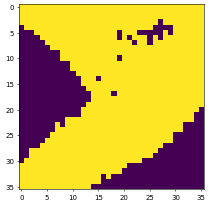

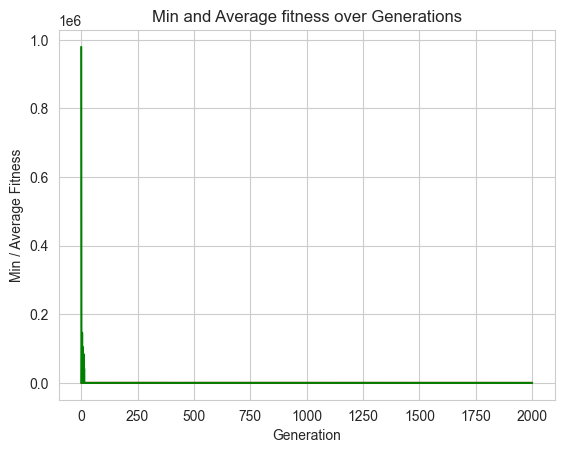

In [34]:
if __name__ == "__main__":
    start = time.time()
    top_ = main()
    end = time.time()


Final Cantilever beam design:


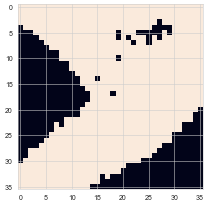

In [35]:
draw(top_)

### RL model

In [36]:
class Model:
    def __init__(self, x):
        self.flag_ = True
        self.n, self.m = x.shape
        self.actions_dic={} 
    
        k=0
        for i in range(self.n):
            for j in range(self.m):
                count = 0
                if x[i][j]==1:
                    
                
                    if 0<=i+1<self.n and x[i+1][j]==1:
                        count+=1
                    if 0<=i-1<self.n and x[i-1][j]==1:
                        count+=1 
                    if 0<=j+1<self.m and x[i][j+1]==1:
                        count+=1
                    if 0<=j-1<self.m and x[i][j-1]==1:
                        count+=1   
                
                    if count<4:
                        self.actions_dic[k]=(i,j)
                        k+=1
                        
                elif  x[i][j]==0:
                    x[i][j]+=1e-4
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1e-4
        
    def draw(self,X):  
        plt.figure(dpi=50) 
        print('\nFinal Cantilever beam design:')
        plt.imshow(X) 
        plt.show()        

In [37]:
class CantileverEnv(gymnasium.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self,x1, y1, topology_slice):
        super().__init__()
        self.x0=x1
        self.y0=y1
        self.topology_slice = topology_slice
        
        self.x = self.topology_slice.copy()
    
        self.M=Model(self.x)

        DIM =  self.x0 * self.y0
        N_DISCRETE_ACTIONS = len(self.M.actions_dic)
       
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=np.array([-1e10 for x in range(DIM)]),
                                            high=np.array([1e10 for y in range(DIM)]),
                                            shape=(DIM,),
                                           dtype=np.float64)
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        self.ext_reward=0

        
    def step(self, action):
        
        self.M.action_space_(action, self.x)        
        self.step_+=1
               
        done=False
                  
        if self.step_ > 0.8*self.x0 * self.y0:                    # to tune 
            done=True            
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            self.needs_reset = True
                         
        
        return self.x.reshape(self.x.shape[0]*self.x.shape[1]), self.ext_reward, done, False, dict()

    def reset(self, seed=0):
                   
        self.x = self.topology_slice.copy()

        self.reward=0
        self.needs_reset = False
        self.step_=0
        self.ext_reward=0

        return self.x.reshape(self.x.shape[0]*self.x.shape[1]),{}

    def render(self, mode="human"):
        pass   

    def close(self):
        pass

In [38]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            
            
            
            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")

            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                
                mean_reward = np.mean(y[-100:])
                
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [39]:
def reconstruct_3d_structure(xy_plane, yz_plane, xz_plane):
    """
    Reconstructs a 3D structure from three 2D projections using extrusion and intersection.

    Parameters:
        xy_plane (ndarray): 2D binary array (X by Y) projection in XY plane.
        yz_plane (ndarray): 2D binary array (Y by Z) projection in YZ plane.
        xz_plane (ndarray): 2D binary array (X by Z) projection in XZ plane.

    Returns:
        volume (ndarray): 3D binary array (X by Y by Z) representing the reconstructed structure.
    """
    x_dim, y_dim = xy_plane.shape
    y_dim2, z_dim = yz_plane.shape
    x_dim2, z_dim2 = xz_plane.shape

    assert x_dim == x_dim2, "X dimensions mismatch between XY and XZ planes."
    assert y_dim == y_dim2, "Y dimensions mismatch between XY and YZ planes."
    assert z_dim == z_dim2, "Z dimensions mismatch between YZ and XZ planes."

    # Extrude XY along Z
    xy_extruded = np.repeat(xy_plane[:, :, np.newaxis], z_dim, axis=2)

    # Extrude YZ along X
    yz_extruded = np.repeat(yz_plane[np.newaxis, :, :], x_dim, axis=0)

    # Extrude XZ along Y
    xz_extruded = np.repeat(xz_plane[:, np.newaxis, :], y_dim, axis=1)

    # Intersect all three extrusions
    volume = xy_extruded & yz_extruded & xz_extruded

    return volume.astype(np.uint8)  # or bool, depending on your needs

In [40]:
def compute_single_reward(args_tuple):
    grid_data, action_slice, task_index, x0, y0 = args_tuple
    
    gr = deconstruct(grid_data, action_slice.reshape(x0//4, y0//4), task_index, x0, y0)
    constI = np.sum(gr) / (x0 * y0)
   
    if constI > 0.65:                     # to tune 
        args = get_args(*mbb_beam(rd=0))
        tmp, const = fast_stopt(args, gr)  
        reward = 1/tmp + 1/calculate_smoothness_metric(gr.reshape(x0, y0))
        if count_islands_dfs(gr) == 1:
            reward *= 10

        return reward, constI
    return 0.0, constI

In [41]:
class CrossRewardEnv(gymnasium.Env):
    def __init__(self):
        super().__init__()
        self.grid = np.where( top_ == 0, 1e-04, top_) 
        self.grid_glob = np.where( top_ == 0, 1e-04, top_)
        self.x0=x0
        self.y0=y0
        
        self.env0 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 0, x0, y0))
        self.env1 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 1, x0, y0))
        self.env2 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 2, x0, y0))
        self.env3 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 3, x0, y0))
        self.env4 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 4, x0, y0))
        self.env5 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 5, x0, y0))
        self.env6 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 6, x0, y0))
        self.env7 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 7, x0, y0))
        self.env8 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 8, x0, y0))
        self.env9 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 9, x0, y0))
        self.env10 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 10, x0, y0))
        self.env11 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 11, x0, y0))
        self.env12 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 12, x0, y0))
        self.env13 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 13, x0, y0))
        self.env14 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 14, x0, y0))
        self.env15 = CantileverEnv(x0//4,y0//4,return_topology_slice(self.grid, 15, x0, y0))

        self.observation_space = spaces.Dict({
            'plane0': self.env0.observation_space,
            'plane1': self.env1.observation_space,
            'plane2': self.env2.observation_space,
            'plane3': self.env3.observation_space,
            'plane4': self.env4.observation_space,
            'plane5': self.env5.observation_space,
            'plane6': self.env6.observation_space,
            'plane7': self.env7.observation_space,
            'plane8': self.env8.observation_space,
            'plane9': self.env9.observation_space,
            'plane10': self.env10.observation_space,
            'plane11': self.env11.observation_space,
            'plane12': self.env12.observation_space,
            'plane13': self.env13.observation_space,
            'plane14': self.env14.observation_space,
            'plane15': self.env15.observation_space,
        })

        self.action_space = spaces.MultiDiscrete([len(self.env0.M.actions_dic),
                                                  len(self.env1.M.actions_dic),
                                                  len(self.env2.M.actions_dic),
                                                  len(self.env3.M.actions_dic),
                                                  len(self.env4.M.actions_dic),
                                                  len(self.env5.M.actions_dic),
                                                  len(self.env6.M.actions_dic),
                                                  len(self.env7.M.actions_dic),
                                                  len(self.env8.M.actions_dic),
                                                  len(self.env9.M.actions_dic),
                                                  len(self.env10.M.actions_dic),
                                                  len(self.env11.M.actions_dic),
                                                  len(self.env12.M.actions_dic),
                                                  len(self.env13.M.actions_dic),
                                                  len(self.env14.M.actions_dic),
                                                  len(self.env15.M.actions_dic)])
        self.step1_ = 0
             
       

    def reset(self, seed=0):
        obs0, info0 = self.env0.reset()
        obs1, info1 = self.env1.reset()
        obs2, info2 = self.env2.reset()
        obs3, info3 = self.env3.reset()
        obs4, info4 = self.env4.reset()
        obs5, info5 = self.env5.reset()
        obs6, info6 = self.env6.reset()
        obs7, info7 = self.env7.reset()
        obs8, info8 = self.env8.reset()
        obs9, info9 = self.env9.reset()
        obs10, info10 = self.env10.reset()
        obs11, info11 = self.env11.reset()
        obs12, info12 = self.env12.reset()
        obs13, info13 = self.env13.reset()
        obs14, info14 = self.env14.reset()
        obs15, info15 = self.env15.reset()
        self.step1_=0
        self.grid_glob = np.where(top_ == 0, 1e-04, top_) 
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        }, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def step(self, action):
        a0 = action[0]
        a1 = action[1]
        a2 = action[2]
        a3 = action[3]
        a4 = action[4]
        a5 = action[5]
        a6 = action[6]
        a7 = action[7]
        a8 = action[8]
        a9 = action[9]
        a10 = action[10]
        a11 = action[11]
        a12 = action[12]
        a13 = action[13]
        a14 = action[14]
        a15 = action[15]
        
        
        obs0, r0, done0,_, info0 = self.env0.step(a0)
        obs1, r1, done1,_, info1 = self.env1.step(a1)
        obs2, r2, done2,_, info2 = self.env2.step(a2)
        obs3, r3, done3,_, info3 = self.env3.step(a3)
        obs4, r4, done4,_, info4 = self.env4.step(a4)
        obs5, r5, done5,_, info5 = self.env5.step(a5)
        obs6, r6, done6,_, info6 = self.env6.step(a6)
        obs7, r7, done7,_, info7 = self.env7.step(a7)
        obs8, r8, done8,_, info8 = self.env8.step(a8)
        obs9, r9, done9,_, info9 = self.env9.step(a9)
        obs10, r10, done10,_, info10 = self.env10.step(a10)
        obs11, r11, done11,_, info11 = self.env11.step(a11)
        obs12, r12, done12,_, info12 = self.env12.step(a12)
        obs13, r13, done13,_, info13 = self.env13.step(a13)
        obs14, r14, done14,_, info14 = self.env14.step(a14)
        obs15, r15, done15,_, info15 = self.env15.step(a15)
       
        OBS=[obs0,obs1,obs2,obs3,obs4,obs5,obs6,obs7,obs8,obs9,obs10,obs11,obs12,obs13,obs14,obs15]    
        RE =[self.env0.ext_reward,
             self.env1.ext_reward,
             self.env2.ext_reward,
             self.env3.ext_reward,
             self.env4.ext_reward,
             self.env5.ext_reward,
             self.env6.ext_reward,
             self.env7.ext_reward,
             self.env8.ext_reward,
             self.env9.ext_reward,
             self.env10.ext_reward,
             self.env11.ext_reward,
             self.env12.ext_reward,
             self.env13.ext_reward,
             self.env14.ext_reward,
             self.env15.ext_reward,
            ] 
        
        task_args = []
       
        for i in range(len(OBS)):
            task_args.append((self.grid, OBS[i], i, self.x0, self.y0))
            self.grid_glob = deconstruct(self.grid_glob, OBS[i].reshape(self.x0//4,self.y0//4), i, self.x0, self.y0)
        results  = pool.map(compute_single_reward, task_args)
        rewards_list, coI = zip(*results)
    
        for i in range(len(OBS)): 
            RE[i]=rewards_list[i] 
                            
        self.step1_+=1
     
        Do=(np.sum(coI)/len(OBS) > 0.67)                     # to tune 
        done = (done0 or done1 or done2 or done3 or done4 or done5 or done6 or
        done7 or done8 or done9 or done10 or done11 or done12 or done13 or done14 or done15 or bool(Do))
        
        args_glob = get_args(*mbb_beam(rd=0))
        tmp_glob, const_glob = fast_stopt(args_glob, self.grid_glob)
        REW = 1/tmp_glob + 1/calculate_smoothness_metric(self.grid_glob.reshape(x0, y0))
        if count_islands_dfs(self.grid_glob) == 1:
            REW *= 10
         
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        },  REW, done, False, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def render(self, mode='human'):    
        pass

    def close(self):
        self.env0.close()
        self.env1.close()
        self.env2.close()
        self.env3.close()
        self.env4.close()
        self.env5.close()
        self.env6.close()
        self.env7.close()
        self.env8.close()
        self.env9.close()
        self.env10.close()
        self.env11.close()
        self.env12.close()
        self.env13.close()
        self.env14.close()
        self.env15.close()

### Training 

In [42]:
ts = 0.5e6

In [43]:
# Create log dir
log_dir = "/tmp/gym7_v3aleof1qaz123/"
os.makedirs(log_dir, exist_ok=True)

In [44]:
callback = SaveOnBestTrainingRewardCallback(check_freq = 100_000, log_dir=log_dir)

In [45]:
env=CrossRewardEnv()
check_env(env)
env  = Monitor(env, log_dir)

In [46]:
start = time.time()
model = PPO("MultiInputPolicy", env).learn(total_timesteps=ts, callback=callback)
end = time.time()  

Num timesteps: 100000
Best mean reward: -inf - Last mean reward per episode: 0.50
Saving new best model to /tmp/gym7_v3aleof1qaz123/best_model.zip


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/giga/Library/Python/3.9/lib/python/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/6q/zp3bjthx3zv4n0bl2l835qdw0000gn/T/ipykernel_7178/381011229.py", line 2, in <module>
    model = PPO("MultiInputPolicy", env).learn(total_timesteps=ts, callback=callback)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/ppo/ppo.py", line 315, in learn
    return super().learn(
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/on_policy_algorithm.py", line 300, in learn
    continue_training = self.collect_rollouts(self.env, callback, self.rollout_buffer, n_rollout_steps=self.n_steps)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/on_policy_algorithm.py", line 195, in collect_rollo

  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/pool.py", line 114, in worker
    task = get()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/pool.py", line 114, in worker
    task = get()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/pool.py", line 114, in worker
    task = get()
  File "/Library/Frameworks/Python.fr

In [ ]:
print('Total time taken: {} min'.format((end - start)/60))

### Inference

In [47]:
def construct(obs_dict, env_idx=0):
    grid = np.zeros((x0, y0), dtype=int)
    for i in range(16):
        plane = obs_dict[i]['plane{}'.format(i)]  
        row_offset = (i // 4) * (x0 // 4)
        col_offset = (i % 4) * (x0 // 4)
        grid[row_offset:row_offset + x0//4, col_offset:col_offset + x0//4] = plane.reshape(x0//4, y0//4)
    return grid

In [ ]:
obs = env.reset()

In [ ]:
obs = obs[0]

In [ ]:
ans=[]
for i in range(1000):
    action, _states = model.predict(obs)
    obs, rewards, dones,_, infos = env.step(action)
    ans.append(obs)
    if dones:   
        break

In [ ]:
OBS = [ans[-1] for i in range(16)]

grid = construct(OBS)

In [ ]:
grid

In [ ]:
draw(grid)

In [ ]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [ ]:
obs = env.reset()

In [ ]:
obs = obs[0]

In [ ]:
model_best = PPO.load(log_dir + "best_model.zip", env = env)

In [ ]:
ans=[]
for i in range(1000):
    action, _states = model_best.predict(obs)
    obs, rewards, dones, _,infos = env.step(action)
    ans.append(obs)
    if dones:   
        break

In [52]:
OBS = [ans[-1] for i in range(16)]
grid = construct(OBS)


Final Cantilever beam design:


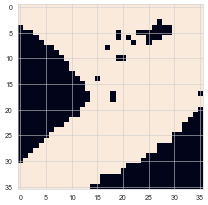

In [53]:
draw(grid)

In [54]:
args = get_args(*mbb_beam(rd=0))
tmp, const = fast_stopt(args, grid.astype(float))

In [55]:
tmp

22.948988328818977

In [56]:
const

0.6875

In [57]:
grid

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

In [58]:
arr = grid

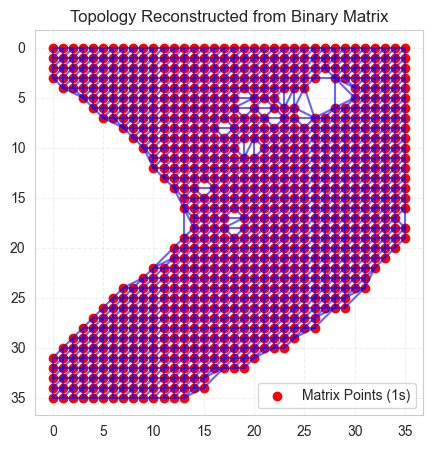

Topological Features found:
Hole/Loop exists from radius 0.25 to 3.3800000000000012
Hole/Loop exists from radius 0.25 to 1.25
Hole/Loop exists from radius 0.25 to 1.25
Hole/Loop exists from radius 0.25 to 1.25
Hole/Loop exists from radius 0.25 to 1.0
Hole/Loop exists from radius 0.25 to 1.0
Hole/Loop exists from radius 0.25 to 1.0
Hole/Loop exists from radius 0.5 to 1.0
Hole/Loop exists from radius 1.0 to 1.25
Hole/Loop exists from radius 2.25 to 2.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop exists from radius 0.25 to 0.5
Hole/Loop ex

In [59]:
# 1. Convert Matrix to Point Cloud
# np.argwhere finds indices where value is 1
points = np.argwhere(arr == 1)

# 2. Build the Alpha Complex
# This reconstructs the topological structure from the discrete points
alpha_complex = gd.AlphaComplex(points=points)
simplex_tree = alpha_complex.create_simplex_tree()

# 3. Visualization
plt.figure(figsize=(5, 5))

# Plot the original matrix points
plt.scatter(points[:, 1], points[:, 0], c='red', label='Matrix Points (1s)')

# Reconstruct and plot the edges (1-simplices)
# Adjust alpha_threshold to "connect" points at different distances
alpha_threshold = 3
for simplex, filtration in simplex_tree.get_skeleton(1):
    if len(simplex) == 2 and filtration < alpha_threshold:
        p1, p2 = points[simplex[0]], points[simplex[1]]
        # Note: argwhere returns (row, col), so we plot (col, row) for (x, y)
        plt.plot([p1[1], p2[1]], [p1[0], p2[0]], 'b-', alpha=0.6)

plt.gca().invert_yaxis() # Match matrix coordinate system (top-down)
plt.title("Topology Reconstructed from Binary Matrix")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Extract Topological Invariants
persistence = simplex_tree.persistence()
print("Topological Features found:")
for dim, (birth, death) in persistence:
    feature_type = "Component" if dim == 0 else "Hole/Loop"
    print(f"{feature_type} exists from radius {birth} to {death}")

In [60]:
pool.close()   
pool.join()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/giga/Library/Python/3.9/lib/python/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/6q/zp3bjthx3zv4n0bl2l835qdw0000gn/T/ipykernel_7178/3977446095.py", line 2, in <module>
    pool.join()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pathos/multiprocessing.py", line 241, in join
    _pool.join()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/pool.py", line 662, in join
    self._worker_handler.join()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/threading.py", line 1053, in join
    self._wait_for_tstate_lock()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/threading.py", line 1069, in _wait_for_tstate_lock
    elif lock.acquire(block, timeout):
KeyboardInterrupt

During handling of the above exceptio